### OVERALL MODEL SUMMARY    
The performance metrics and feature importance from the various classifiers are summarized.

**Import the required libraries**

In [1]:
!pip install groq
from groq import Groq
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
import shap
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import MinMaxScaler

##Overall Performance Metrics

Load the **performance metrics** of the different classifiers.

In [2]:
# Load the Decision Tree metrics
dtree_model_df = pd.read_csv('dtree_metrics.csv')

print(dtree_model_df.head())

           Model  ROC_AUC  Accuracy  Precision  Recall  False_Negatives  \
0  Decision Tree    0.988  0.938596   0.857143     1.0                0   

   False_Positives  
0                7  


In [3]:
# Load the Random Forest metrics
rf_model_df = pd.read_csv('rf_metrics.csv')

print(rf_model_df.head())

  Model  ROC_AUC  Accuracy  Precision  Recall  False_Negatives  \
0    RF    0.997  0.973684   0.933333     1.0                0   

   False_Positives  
0                3  


In [4]:
# Load the XGBoost metrics
xgb_model_df = pd.read_csv('xgb_metrics.csv')

print(xgb_model_df.head())

  Model  ROC_AUC  Accuracy  Precision  Recall  False_Negatives  \
0   XGB    0.997  0.973684   0.933333     1.0                0   

   False_Positives  
0                3  


In [5]:
# Load the GaussianNB metrics
gnb_model_df = pd.read_csv('gnb_metrics.csv')

print(gnb_model_df.head())

  Model  ROC_AUC  Accuracy  Precision  Recall  False_Negatives  \
0   GNB    0.991   0.95614   0.893617     1.0                0   

   False_Positives  
0                5  


In [6]:
# Load the Keras metrics
keras_model_df = pd.read_csv('keras_metrics.csv')

print(keras_model_df.head())

   Model  ROC_AUC  Accuracy  Precision  Recall  False_Negatives  \
0  Keras    0.994  0.868421   0.736842     1.0                0   

   False_Positives  
0               15  


In [7]:
# Load the SVC metrics
svc_model_df = pd.read_csv('svc_metrics.csv')

print(svc_model_df.head())

  Model  ROC_AUC  Accuracy  Precision  Recall  False_Negatives  \
0   SVC    0.993  0.947368      0.875     1.0                0   

   False_Positives  
0                6  


In [8]:
# Load the KNN metrics
knn_model_df = pd.read_csv('knn_metrics.csv')

print(knn_model_df.head())

  Model  ROC_AUC  Accuracy  Precision  Recall  False_Negatives  \
0   KNN    0.995  0.929825       0.84     1.0                0   

   False_Positives  
0                8  


In [9]:
# Load the Logistic Regression metrics
lgr_model_df = pd.read_csv('lgr_metrics.csv')

print(lgr_model_df.head())

                 Model  ROC_AUC  Accuracy  Precision  Recall  False_Negatives  \
0  Logistic_Regression    0.995  0.929825       0.84     1.0                0   

   False_Positives  
0                8  


**Combine** the performance metrics dataframes

In [14]:
# Combine the dataframes
overall_metrics_df = pd.concat([dtree_model_df, rf_model_df, keras_model_df, xgb_model_df,
                lgr_model_df, gnb_model_df, svc_model_df, knn_model_df], ignore_index=True)

print(overall_metrics_df.head(7))

                 Model  ROC_AUC  Accuracy  Precision  Recall  False_Negatives  \
0        Decision Tree    0.988  0.938596   0.857143     1.0                0   
1                   RF    0.997  0.973684   0.933333     1.0                0   
2                Keras    0.994  0.868421   0.736842     1.0                0   
3                  XGB    0.997  0.973684   0.933333     1.0                0   
4  Logistic_Regression    0.995  0.929825   0.840000     1.0                0   
5                  GNB    0.991  0.956140   0.893617     1.0                0   
6                  SVC    0.993  0.947368   0.875000     1.0                0   

   False_Positives  
0                7  
1                3  
2               15  
3                3  
4                8  
5                5  
6                6  


In [15]:
# Prepare for plotting without 'False_Negatives'
overall_metrics_df = overall_metrics_df.drop(columns=['False_Negatives'])
overall_metrics_df = overall_metrics_df.sort_values(by=['False_Positives'])
overall_metrics_df

,Model,ROC_AUC,Accuracy,Precision,Recall,False_Positives
1,RF,0.997,0.973684,0.933333,1.0,3
3,XGB,0.997,0.973684,0.933333,1.0,3
5,GNB,0.991,0.956140,0.893617,1.0,5
6,SVC,0.993,0.947368,0.875000,1.0,6
0,Decision Tree,0.988,0.938596,0.857143,1.0,7
4,Logistic_Regression,0.995,0.929825,0.840000,1.0,8
7,KNN,0.995,0.929825,0.840000,1.0,8
2,Keras,0.994,0.868421,0.736842,1.0,15


In [16]:
# Provide an interactive Plotly plot
fig = go.Figure()

#Primary y-axis
metrics = ['ROC_AUC', 'Accuracy', 'Precision', 'Recall', 'False_Positives']

for metric in metrics:
  fig.add_trace(
        go.Scatter(
          x=overall_metrics_df['Model'],
          y=overall_metrics_df[metric],
          mode='lines+markers',
          name=metric,
          yaxis='y1'
        )
    )

# Secondary y-axis
fig.add_trace(
        go.Bar(
          x=overall_metrics_df['Model'],
          y=overall_metrics_df['False_Positives'],
          name='Profit/Loss',
          yaxis='y2',
          opacity=0.35
        )
)
# Layout
fig.update_layout(
        title='Model Performance',
        xaxis=dict(title='Model'),
        yaxis=dict(
            title='Score',
            range=[0, 1]
        ),
        yaxis2=dict(
            title='False_Positives',
            overlaying='y',
            side='right'
        ),
        legend=dict(
            orientation='h',
            yanchor='bottom',
            y=1.02,
            xanchor='right',
            x=1
        ),
        template='plotly_white',
        hovermode='x unified'
)
fig.show()

**Random Forest** and **XGBoost** are tied for the best model based on minimum false positives.

In [17]:
# Get the best model performance metrics based on minimum 'False Positives'
best_model_df = overall_metrics_df.loc[[overall_metrics_df["False_Positives"].idxmin()]]

best_model_df.head()

,Model,ROC_AUC,Accuracy,Precision,Recall,False_Positives
1,RF,0.997,0.973684,0.933333,1.0,3


##Overall Feature Importance

Load the **feature importance** of the top four (4) classifiers, namely, **Random Forest Classifier**, **XGBoost Classifier**, **GaussianNB Classifier**, and **SVC Classifier**.

In [18]:
# Load the Random Forest feature importance
rf_features_df = pd.read_csv('rf_features.csv')

print(rf_features_df.head(8))

             feature  importance
0    smoothness_mean    0.096671
1       concavity_se    0.098484
2     symmetry_worst    0.104069
3  concave points_se    0.126093
4      texture_worst    0.144588
5   compactness_mean    0.220587
6  compactness_worst    0.220740
7          radius_se    0.232262


In [19]:
# Rename the 'importance' column
rf_features_df = rf_features_df.rename(columns={'importance': 'Random_Forest'})

print(rf_features_df.head(8))

             feature  Random_Forest
0    smoothness_mean       0.096671
1       concavity_se       0.098484
2     symmetry_worst       0.104069
3  concave points_se       0.126093
4      texture_worst       0.144588
5   compactness_mean       0.220587
6  compactness_worst       0.220740
7          radius_se       0.232262


In [20]:
# Load the XGBoost feature importance
xgb_features_df = pd.read_csv('xgb_features.csv')

print(xgb_features_df.head(8))

                  feature  importance_mean
0            perimeter_se         0.000000
1  fractal_dimension_mean         0.000000
2             radius_mean         0.004762
3          compactness_se         0.007143
4         smoothness_mean         0.011905
5           symmetry_mean         0.011905
6              texture_se         0.011905
7          perimeter_mean         0.011905


In [21]:
# Rename the 'importance_mean' column
xgb_features_df = xgb_features_df.rename(columns={'importance_mean': 'XGBoost'})

print(xgb_features_df.head(8))

                  feature   XGBoost
0            perimeter_se  0.000000
1  fractal_dimension_mean  0.000000
2             radius_mean  0.004762
3          compactness_se  0.007143
4         smoothness_mean  0.011905
5           symmetry_mean  0.011905
6              texture_se  0.011905
7          perimeter_mean  0.011905


In [22]:
# Load the XGBoost feature importance
gnb_features_df = pd.read_csv('gnb_features.csv')

print(gnb_features_df.head(8))

                  feature  importance_mean
0     concave points_mean    -1.666667e-02
1             radius_mean    -4.761905e-03
2          concavity_mean    -3.330669e-17
3  fractal_dimension_mean     0.000000e+00
4            radius_worst     2.380952e-03
5         perimeter_worst     4.761905e-03
6       compactness_worst     7.142857e-03
7              texture_se     9.523810e-03


In [23]:
# Rename the 'importance_mean' column
gnb_features_df = gnb_features_df.rename(columns={'importance_mean': 'GaussianNB'})

print(gnb_features_df.head(8))

                  feature    GaussianNB
0     concave points_mean -1.666667e-02
1             radius_mean -4.761905e-03
2          concavity_mean -3.330669e-17
3  fractal_dimension_mean  0.000000e+00
4            radius_worst  2.380952e-03
5         perimeter_worst  4.761905e-03
6       compactness_worst  7.142857e-03
7              texture_se  9.523810e-03


In [24]:
# Load the SVC feature importance
svc_features_df = pd.read_csv('svc_features.csv')

print(svc_features_df.head(8))

            feature  importance_mean
0           area_se        -0.002381
1         radius_se         0.000000
2      perimeter_se         0.004762
3  compactness_mean         0.004762
4     symmetry_mean         0.004762
5        texture_se         0.009524
6   smoothness_mean         0.014286
7         area_mean         0.016667


In [25]:
# Rename the 'importance_mean' column
svc_features_df = svc_features_df.rename(columns={'importance_mean': 'SVC'})

print(svc_features_df.head(8))

            feature       SVC
0           area_se -0.002381
1         radius_se  0.000000
2      perimeter_se  0.004762
3  compactness_mean  0.004762
4     symmetry_mean  0.004762
5        texture_se  0.009524
6   smoothness_mean  0.014286
7         area_mean  0.016667


In [26]:
# Combine feature importance dataframes
feature_comparison_df = (
    svc_features_df
    .merge(rf_features_df, on='feature', how='outer')
    .merge(xgb_features_df, on='feature', how='outer')
    .merge(gnb_features_df, on='feature', how='outer')
)

print(feature_comparison_df.head(28))

                    feature       SVC  Random_Forest   XGBoost    GaussianNB
0                 area_mean  0.016667       0.373242       NaN           NaN
1                   area_se -0.002381       0.348002       NaN           NaN
2                area_worst       NaN       0.453892       NaN           NaN
3          compactness_mean  0.004762       0.220587  0.016667           NaN
4            compactness_se       NaN            NaN  0.007143           NaN
5         compactness_worst       NaN       0.220740       NaN  7.142857e-03
6       concave points_mean  0.021429       0.446689       NaN -1.666667e-02
7         concave points_se       NaN       0.126093  0.016667  1.190476e-02
8      concave points_worst       NaN       0.433306       NaN           NaN
9            concavity_mean  0.026190       0.354876       NaN -3.330669e-17
10             concavity_se       NaN       0.098484       NaN  1.190476e-02
11          concavity_worst       NaN       0.302843       NaN           NaN

In [27]:
# Verify info
feature_comparison_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28 entries, 0 to 27
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   feature        28 non-null     object 
 1   SVC            15 non-null     float64
 2   Random_Forest  20 non-null     float64
 3   XGBoost        15 non-null     float64
 4   GaussianNB     15 non-null     float64
dtypes: float64(4), object(1)
memory usage: 1.2+ KB


In [28]:
# Assign '0.000000' to 'NaN'
num_cols = feature_comparison_df.columns.drop("feature")
feature_comparison_df[num_cols] = feature_comparison_df[num_cols].fillna(0)

print(feature_comparison_df.head(33))

                    feature       SVC  Random_Forest   XGBoost    GaussianNB
0                 area_mean  0.016667       0.373242  0.000000  0.000000e+00
1                   area_se -0.002381       0.348002  0.000000  0.000000e+00
2                area_worst  0.000000       0.453892  0.000000  0.000000e+00
3          compactness_mean  0.004762       0.220587  0.016667  0.000000e+00
4            compactness_se  0.000000       0.000000  0.007143  0.000000e+00
5         compactness_worst  0.000000       0.220740  0.000000  7.142857e-03
6       concave points_mean  0.021429       0.446689  0.000000 -1.666667e-02
7         concave points_se  0.000000       0.126093  0.016667  1.190476e-02
8      concave points_worst  0.000000       0.433306  0.000000  0.000000e+00
9            concavity_mean  0.026190       0.354876  0.000000 -3.330669e-17
10             concavity_se  0.000000       0.098484  0.000000  1.190476e-02
11          concavity_worst  0.000000       0.302843  0.000000  0.000000e+00

In [29]:
# Sort the datafraame
feature_comparison_df = feature_comparison_df.sort_values(by='Random_Forest', ascending=False)

print(feature_comparison_df.head(33))

                    feature       SVC  Random_Forest   XGBoost    GaussianNB
19             radius_worst  0.016667       0.460519  0.000000  2.380952e-03
16          perimeter_worst  0.000000       0.453892  0.269048  4.761905e-03
2                area_worst  0.000000       0.453892  0.000000  0.000000e+00
6       concave points_mean  0.021429       0.446689  0.000000 -1.666667e-02
8      concave points_worst  0.000000       0.433306  0.000000  0.000000e+00
14           perimeter_mean  0.016667       0.411276  0.011905  0.000000e+00
0                 area_mean  0.016667       0.373242  0.000000  0.000000e+00
17              radius_mean  0.016667       0.370025  0.004762 -4.761905e-03
9            concavity_mean  0.026190       0.354876  0.000000 -3.330669e-17
1                   area_se -0.002381       0.348002  0.000000  0.000000e+00
11          concavity_worst  0.000000       0.302843  0.000000  0.000000e+00
15             perimeter_se  0.004762       0.265308  0.000000  0.000000e+00

In [30]:
# Find rows with '0.000000' for three classifiers
feature_zero_df = feature_comparison_df[(feature_comparison_df['SVC'] == 0.000000) & \
      (feature_comparison_df['Random_Forest'] == 0.000000) & (feature_comparison_df['XGBoost'] == 0.000000) & \
      (feature_comparison_df['GaussianNB'] == 0.000000)]

print(feature_zero_df.head(28))

Empty DataFrame
Columns: [feature, SVC, Random_Forest, XGBoost, GaussianNB]
Index: []


In [31]:
# Get index list
index_list = feature_zero_df.index.tolist()

print(index_list)

[]


In [32]:
# Drop rows with zeros only for the three classifiers
feature_comparison_df = feature_comparison_df.drop(index=index_list)

print(feature_comparison_df.head(22))

                   feature       SVC  Random_Forest   XGBoost    GaussianNB
19            radius_worst  0.016667       0.460519  0.000000  2.380952e-03
16         perimeter_worst  0.000000       0.453892  0.269048  4.761905e-03
2               area_worst  0.000000       0.453892  0.000000  0.000000e+00
6      concave points_mean  0.021429       0.446689  0.000000 -1.666667e-02
8     concave points_worst  0.000000       0.433306  0.000000  0.000000e+00
14          perimeter_mean  0.016667       0.411276  0.011905  0.000000e+00
0                area_mean  0.016667       0.373242  0.000000  0.000000e+00
17             radius_mean  0.016667       0.370025  0.004762 -4.761905e-03
9           concavity_mean  0.026190       0.354876  0.000000 -3.330669e-17
1                  area_se -0.002381       0.348002  0.000000  0.000000e+00
11         concavity_worst  0.000000       0.302843  0.000000  0.000000e+00
15            perimeter_se  0.004762       0.265308  0.000000  0.000000e+00
18          

In [33]:
# Scale importances
scaler = MinMaxScaler()
feature_comparison_df.iloc[:, 1:] = scaler.fit_transform(feature_comparison_df.iloc[:, 1:])

print(feature_comparison_df.head(22))

                   feature       SVC  Random_Forest   XGBoost  GaussianNB
19            radius_worst  0.222222       1.000000  0.000000    0.571429
16         perimeter_worst  0.027778       0.985611  1.000000    0.642857
2               area_worst  0.027778       0.985610  0.000000    0.500000
6      concave points_mean  0.277778       0.969969  0.000000    0.000000
8     concave points_worst  0.027778       0.940909  0.000000    0.500000
14          perimeter_mean  0.222222       0.893072  0.044248    0.500000
0                area_mean  0.222222       0.810482  0.000000    0.500000
17             radius_mean  0.222222       0.803496  0.017699    0.357143
9           concavity_mean  0.333333       0.770601  0.000000    0.500000
1                  area_se  0.000000       0.755675  0.000000    0.500000
11         concavity_worst  0.027778       0.657612  0.000000    0.500000
15            perimeter_se  0.083333       0.576108  0.000000    0.500000
18               radius_se  0.027778  

In [34]:
# Compute average importance
feature_comparison_df['average_importance'] = (feature_comparison_df[['SVC','GaussianNB','Random_Forest',
                                      'XGBoost']].mean(axis=1)
)

print(feature_comparison_df.head(22))

                   feature       SVC  Random_Forest   XGBoost  GaussianNB  \
19            radius_worst  0.222222       1.000000  0.000000    0.571429   
16         perimeter_worst  0.027778       0.985611  1.000000    0.642857   
2               area_worst  0.027778       0.985610  0.000000    0.500000   
6      concave points_mean  0.277778       0.969969  0.000000    0.000000   
8     concave points_worst  0.027778       0.940909  0.000000    0.500000   
14          perimeter_mean  0.222222       0.893072  0.044248    0.500000   
0                area_mean  0.222222       0.810482  0.000000    0.500000   
17             radius_mean  0.222222       0.803496  0.017699    0.357143   
9           concavity_mean  0.333333       0.770601  0.000000    0.500000   
1                  area_se  0.000000       0.755675  0.000000    0.500000   
11         concavity_worst  0.027778       0.657612  0.000000    0.500000   
15            perimeter_se  0.083333       0.576108  0.000000    0.500000   

In [35]:
# Sort by average importance to get the top features
feature_comparison_df = feature_comparison_df.sort_values('average_importance', ascending=False
)

print(feature_comparison_df.head(22))

                    feature       SVC  Random_Forest   XGBoost  GaussianNB  \
16          perimeter_worst  0.027778       0.985611  1.000000    0.642857   
27            texture_worst  1.000000       0.313967  0.318584    0.928571   
19             radius_worst  0.222222       1.000000  0.000000    0.571429   
14           perimeter_mean  0.222222       0.893072  0.044248    0.500000   
9            concavity_mean  0.333333       0.770601  0.000000    0.500000   
0                 area_mean  0.222222       0.810482  0.000000    0.500000   
2                area_worst  0.027778       0.985610  0.000000    0.500000   
8      concave points_worst  0.027778       0.940909  0.000000    0.500000   
17              radius_mean  0.222222       0.803496  0.017699    0.357143   
20          smoothness_mean  0.194444       0.209918  0.044248    0.928571   
1                   area_se  0.000000       0.755675  0.000000    0.500000   
6       concave points_mean  0.277778       0.969969  0.000000  

In [36]:
# Reset index
feature_comparison_df = feature_comparison_df.reset_index(drop=True)
feature_comparison_df.index = feature_comparison_df.index + 1
feature_comparison_df.index.name = "Rank"

feature_comparison_df.head(10)

,feature,SVC,Random_Forest,XGBoost,GaussianNB,average_importance
Rank,,,,,,
1,perimeter_worst,0.027778,0.985611,1.000000,0.642857,0.664062
2,texture_worst,1.000000,0.313967,0.318584,0.928571,0.640281
3,radius_worst,0.222222,1.000000,0.000000,0.571429,0.448413
4,perimeter_mean,0.222222,0.893072,0.044248,0.500000,0.414885
5,concavity_mean,0.333333,0.770601,0.000000,0.500000,0.400984
6,area_mean,0.222222,0.810482,0.000000,0.500000,0.383176
7,area_worst,0.027778,0.985610,0.000000,0.500000,0.378347
8,concave points_worst,0.027778,0.940909,0.000000,0.500000,0.367172
9,radius_mean,0.222222,0.803496,0.017699,0.357143,0.350140


In [37]:
# Move last column to second column
cols = feature_comparison_df.columns.tolist()

# Extract last column
last_col = cols[-1]

# Remove it from the end
cols = cols[:-1]

# Insert it into position 1 (second column)
cols.insert(1, last_col)

# Reorder dataframe
feature_comparison_df = feature_comparison_df[cols]

feature_comparison_df.head(10)

,feature,average_importance,SVC,Random_Forest,XGBoost,GaussianNB
Rank,,,,,,
1,perimeter_worst,0.664062,0.027778,0.985611,1.000000,0.642857
2,texture_worst,0.640281,1.000000,0.313967,0.318584,0.928571
3,radius_worst,0.448413,0.222222,1.000000,0.000000,0.571429
4,perimeter_mean,0.414885,0.222222,0.893072,0.044248,0.500000
5,concavity_mean,0.400984,0.333333,0.770601,0.000000,0.500000
6,area_mean,0.383176,0.222222,0.810482,0.000000,0.500000
7,area_worst,0.378347,0.027778,0.985610,0.000000,0.500000
8,concave points_worst,0.367172,0.027778,0.940909,0.000000,0.500000
9,radius_mean,0.350140,0.222222,0.803496,0.017699,0.357143


In [38]:
# Pick the first ten top feature importance
feature_comparison_df = feature_comparison_df.iloc[:10, :2]

feature_comparison_df.head(10)

,feature,average_importance
Rank,,
1,perimeter_worst,0.664062
2,texture_worst,0.640281
3,radius_worst,0.448413
4,perimeter_mean,0.414885
5,concavity_mean,0.400984
6,area_mean,0.383176
7,area_worst,0.378347
8,concave points_worst,0.367172
9,radius_mean,0.350140


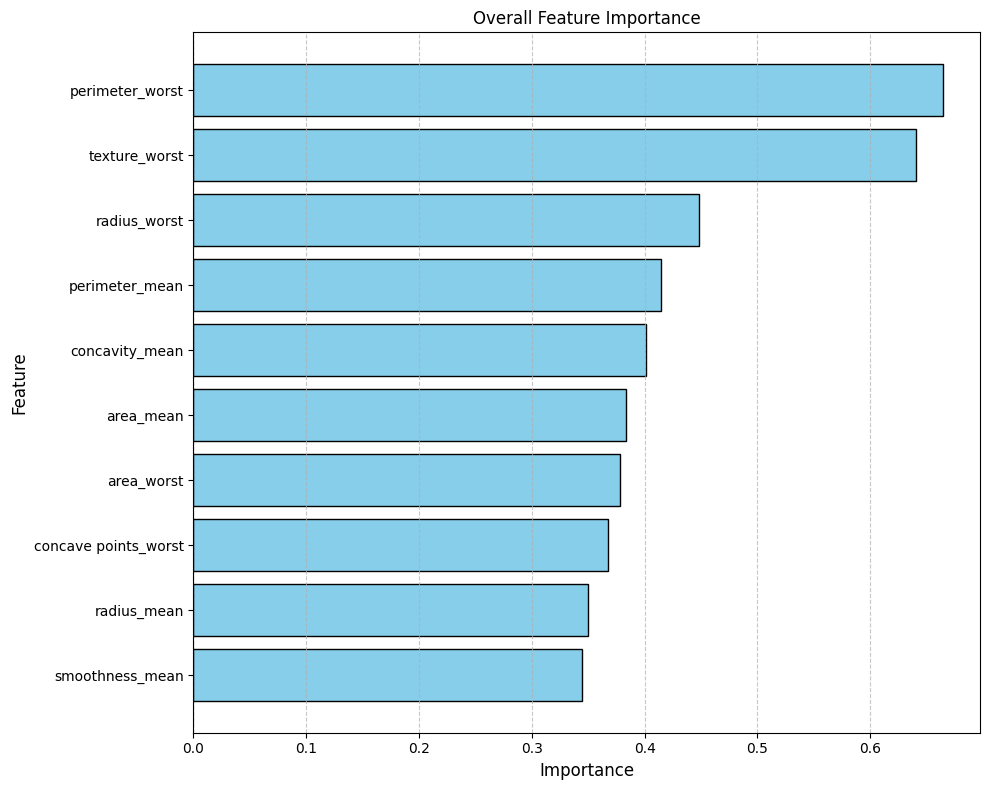

In [39]:
# Plot the feature importance
feature_comparison_df = feature_comparison_df.sort_values(by='average_importance')
plt.figure(figsize=(10, 8))
colors = ['salmon' if x < 0 else 'skyblue' for x in feature_comparison_df['average_importance']]
plt.barh(feature_comparison_df['feature'], feature_comparison_df['average_importance'], color=colors, edgecolor='black')
plt.axvline(x=0, color='black', linestyle='--', linewidth=0.8)
plt.title('Overall Feature Importance')
plt.xlabel('Importance', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

**Gen AI** narrative on feature importance     
The following codes are commented because the API key can only be accessed locally. However, the Gen AI narrative is captured and shown.

In [ ]:
# Convert dataframe to string format
#data_string = feature_comparison_df.to_string(index=False).replace('\n', ' ')
#data_dict = {"data": data_string}

In [40]:
# Provide the API key
#import os

#client = Groq(
#    api_key=os.getenv("GROQ_API_KEY")
#)

In [41]:
# Send the feature importance data for analysis
#chat_completion = client.chat.completions.create(
#    messages=[
#        {"role": "user", "content": f"Analyze the following feature importance data on breast cancer diagnostics: {data_dict['data']}"}
#    ],
#    model="llama-3.1-8b-instant",
#)

#narrative = chat_completion.choices[0].message.content
#narrative = narrative.replace('\n', ' ')

In [42]:
# Obtain the narrative or report from the GenAI model
#from IPython.display import Markdown

#Markdown(narrative)

##Gen AI narrative on feature importance

Based on the provided feature importance data, here's an analysis of the most important features in breast cancer diagnostics: Key Insights: 1. Texture_worst is the most important feature, with an average importance score of 0.640281. This suggests that the texture of the tumor, especially in its worst state, is a strong predictor of breast cancer diagnosis. 2. Perimeter_worst, the second most important feature, has an average importance score of 0.664062. This indicates that the perimeter of the tumor in its worst state is also a crucial factor in breast cancer diagnosis. 3. The radius of the tumor, both in its mean and worst state, is relatively important, with average importance scores of 0.350140 and 0.448413, respectively. This suggests that the size of the tumor is a significant factor in breast cancer diagnosis. 4. The shape of the tumor, as represented by features like concave points, area, and perimeter, is relatively important, with average importance scores ranging from 0.344295 to 0.400984. Key Observations: 1. The smoothness of the tumor, represented by the smoothness_mean feature, is the least important feature, with an average importance score of 0.344295. This suggests that the smoothness of the tumor is not a significant predictor of breast cancer diagnosis. 2. There is a notable difference in the importance scores between texture_worst (0.640281) and the other features. This indicates that the worst-case scenario of the texture feature is much more important than the mean or other features. 3. The feature importance scores show a gradual increase from smoothness_mean to area_worst, suggesting a positive relationship between the importance of these features and the severity or "worseness" of the tumor characteristics. Conclusion: Based on the feature importance data, texture_worst and perimeter_worst are the most important features in breast cancer diagnostics, followed by radius_worst and other shape-related features. These findings suggest that the texture and perimeter of the tumor, especially in its worst state, are critical factors in predicting breast cancer diagnosis. Recommendations: 1. Use texture_worst and perimeter_worst as the primary features for breast cancer diagnosis models. 2. Consider combining features like texture_worst, perimeter_worst, and radius_worst to create a composite feature that captures the most important characteristics of the tumor. 3. Investigate the relationship between the feature importance scores and the underlying biology of breast cancer to better understand the mechanisms driving these findings.

## OVERALL MODEL SUMMARY  

Based on the metrics of  AUC, Accuracy, Precision, Recall, and False_Positives,  **Random Forest Classifier** and **XGBoost Classifier** are tied for first place.


##Next Steps and Further Recommendations    
- Confirm the models suit real and larger clinical data.    
- Continue model development to further reduce false positives.
